In [2]:
# Machine Learning Lab Session 7: Linear Regression and Regularization

# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



In [3]:
# Load dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame



In [4]:
# Explore dataset
print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values in each column:\n", df.isnull().sum())

print("\nDataset head:")
print(df.head())

print("\nDataset description:")
print(df.describe())


Dataset shape: (20640, 9)

Columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']

Missing values in each column:
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Dataset head:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Dataset de

In [5]:
## Prepare Data: Split Features and Target
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

print("\nFeature matrix shape:", X.shape)
print("Target vector shape:", y.shape)


Feature matrix shape: (20640, 8)
Target vector shape: (20640,)


In [7]:
## Train-Test Split and Feature Scaling

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nTraining features shape:", X_train_scaled.shape)
print("Testing features shape:", X_test_scaled.shape)


Training features shape: (16512, 8)
Testing features shape: (4128, 8)


In [8]:
## Train Linear Regression Model
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)
linear_pred = linear_model.predict(X_test_scaled)

Linear Regression evaluation
MAE: 0.5332
MSE: 0.5559
RMSE: 0.7456
R²: 0.5758


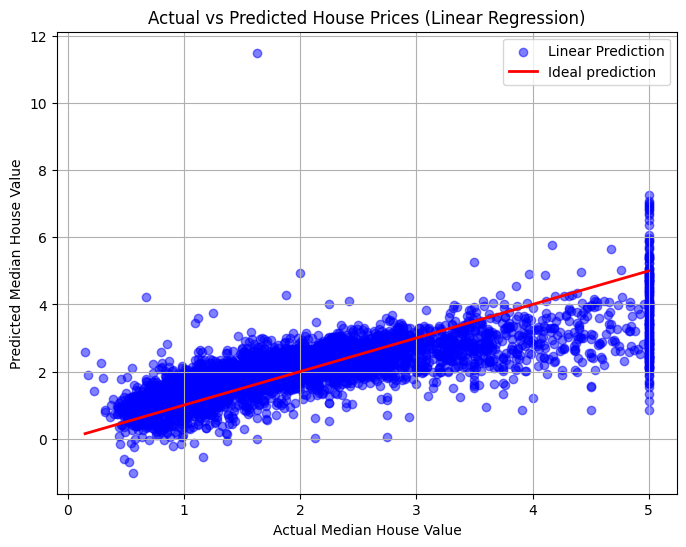

In [9]:
## Evaluate Linear Regression with Metrics
linear_mae = mean_absolute_error(y_test, linear_pred)
linear_mse = mean_squared_error(y_test, linear_pred)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, linear_pred)

print("Linear Regression evaluation")
print(f"MAE: {linear_mae:.4f}")
print(f"MSE: {linear_mse:.4f}")
print(f"RMSE: {linear_rmse:.4f}")
print(f"R²: {linear_r2:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(y_test, linear_pred, color='blue', alpha=0.5, label='Linear Prediction')
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red', linewidth=2, label='Ideal prediction'
)
plt.xlabel('Actual Median House Value')
plt.ylabel('Predicted Median House Value')
plt.title('Actual vs Predicted House Prices (Linear Regression)')
plt.legend()
plt.grid(True)
plt.show()



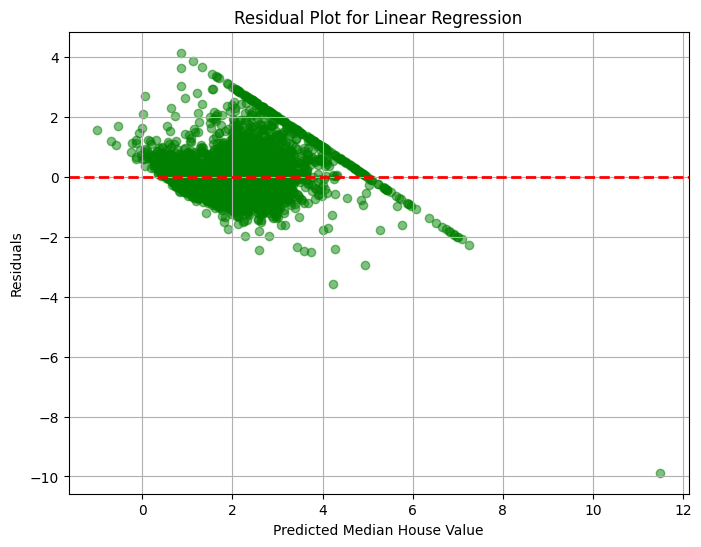

In [10]:
## Create Residual Plot for Diagnostics

residuals = y_test - linear_pred
plt.figure(figsize=(8, 6))
plt.scatter(linear_pred, residuals, color='green', alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Median House Value')
plt.ylabel('Residuals')
plt.title('Residual Plot for Linear Regression')
plt.grid(True)
plt.show()



In [11]:
## Train Ridge Regression Model
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)
ridge_pred = ridge_model.predict(X_test_scaled)

ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(y_test, ridge_pred)

print("\nRidge Regression evaluation")
print(f"MAE: {ridge_mae:.4f}")
print(f"MSE: {ridge_mse:.4f}")
print(f"RMSE: {ridge_rmse:.4f}")
print(f"R²: {ridge_r2:.4f}")




Ridge Regression evaluation
MAE: 0.5332
MSE: 0.5559
RMSE: 0.7456
R²: 0.5758


In [12]:
## Train Lasso Regression Model

lasso_model = Lasso(alpha=0.1, max_iter=10000)
lasso_model.fit(X_train_scaled, y_train)
lasso_pred = lasso_model.predict(X_test_scaled)

lasso_mae = mean_absolute_error(y_test, lasso_pred)
lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test, lasso_pred)

print("\nLasso Regression evaluation")
print(f"MAE: {lasso_mae:.4f}")
print(f"MSE: {lasso_mse:.4f}")
print(f"RMSE: {lasso_rmse:.4f}")
print(f"R²: {lasso_r2:.4f}")



Lasso Regression evaluation
MAE: 0.6222
MSE: 0.6796
RMSE: 0.8244
R²: 0.4814


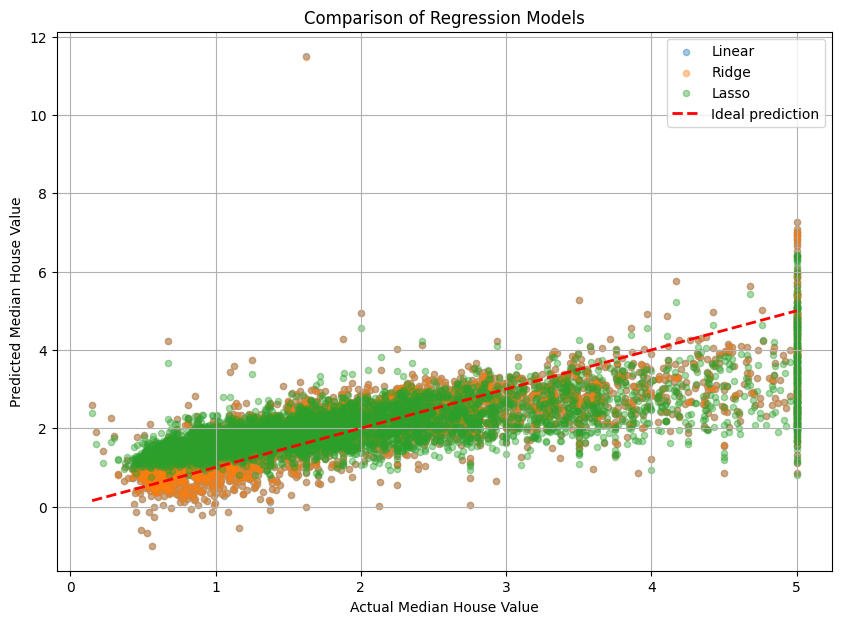

In [13]:

## Compare Linear, Ridge, and Lasso Models

plt.figure(figsize=(10, 7))
plt.scatter(y_test, linear_pred, alpha=0.4, label='Linear', s=20)
plt.scatter(y_test, ridge_pred, alpha=0.4, label='Ridge', s=20)
plt.scatter(y_test, lasso_pred, alpha=0.4, label='Lasso', s=20)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--', linewidth=2, label='Ideal prediction'
)
plt.xlabel('Actual Median House Value')
plt.ylabel('Predicted Median House Value')
plt.title('Comparison of Regression Models')
plt.legend()
plt.grid(True)
plt.show()